In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import featuretools as ft
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import pandas as pd


In [2]:
es = ft.demo.load_retail()

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer forma

In [3]:
print(es)

Entityset: demo_retail_data
  DataFrames:
    order_products [Rows: 401604, Columns: 8]
    products [Rows: 3684, Columns: 4]
    orders [Rows: 22190, Columns: 6]
    customers [Rows: 4372, Columns: 3]
  Relationships:
    order_products.product_id -> products.product_id
    order_products.order_id -> orders.order_id
    orders.customer_name -> customers.customer_name


In [4]:
orders_products = es["order_products"]
products = es["products"]
orders = es["orders"]
customers = es["customers"]

In [5]:
merged_df = orders_products.merge(products, on="product_id", how="left", suffixes=('', '_prod'))
merged_df = merged_df.merge(orders, on="order_id", how="left", suffixes=('', '_ord'))
merged_df = merged_df.merge(customers, on="customer_name", how="left",suffixes=('', '_cust'))

merged_df.head()

,order_product_id,order_id,product_id,quantity,order_date,unit_price,total,_ft_last_time,description,first_order_products_time,_ft_last_time_prod,customer_name,country,cancelled,first_order_products_time_ord,_ft_last_time_ord,first_orders_time,_ft_last_time_cust
0,0,536365,85123A,6,2010-12-01 08:26:00,4.2075,25.245,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-01 08:26:00,2011-12-09 11:34:00,Andrea Brown,United Kingdom,False,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2011-02-10 14:38:00
1,1,536365,71053,6,2010-12-01 08:26:00,5.5935,33.561,2010-12-01 08:26:00,WHITE METAL LANTERN,2010-12-01 08:26:00,2011-12-07 14:12:00,Andrea Brown,United Kingdom,False,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2011-02-10 14:38:00
2,2,536365,84406B,8,2010-12-01 08:26:00,4.5375,36.300,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,2010-12-01 08:26:00,2011-12-05 14:30:00,Andrea Brown,United Kingdom,False,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2011-02-10 14:38:00
3,3,536365,84029G,6,2010-12-01 08:26:00,5.5935,33.561,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,2010-12-01 08:26:00,2011-12-09 11:26:00,Andrea Brown,United Kingdom,False,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2011-02-10 14:38:00
4,4,536365,84029E,6,2010-12-01 08:26:00,5.5935,33.561,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,2010-12-01 08:26:00,2011-12-09 09:07:00,Andrea Brown,United Kingdom,False,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2011-02-10 14:38:00


In [6]:
merged_df.shape

(401604, 18)

In [8]:
from sklearn.metrics import mean_squared_error, r2_score


def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return r2,rmse

In [9]:
target = merged_df["total"]
X = merged_df.drop(columns=["total"])

In [10]:
X.dtypes

order_product_id                          int64
order_id                               category
product_id                             category
quantity                                  int64
order_date                       datetime64[ns]
unit_price                              float64
_ft_last_time                    datetime64[ns]
description                      string[python]
first_order_products_time        datetime64[ns]
_ft_last_time_prod               datetime64[ns]
customer_name                          category
country                                category
cancelled                                  bool
first_order_products_time_ord    datetime64[ns]
_ft_last_time_ord                datetime64[ns]
first_orders_time                datetime64[ns]
_ft_last_time_cust               datetime64[ns]
dtype: object

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score



cols_to_drop = [
    'order_id', 'product_id', 'customer_name', 'description'
]

numeric_cols = X.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()



X = X.drop(columns=cols_to_drop)

datetime_cols = [
    'order_date', '_ft_last_time', 'first_order_products_time',
    '_ft_last_time_prod', 'first_order_products_time_ord',
    '_ft_last_time_ord', 'first_orders_time', '_ft_last_time_cust'
]

for col in datetime_cols:
    X[f'{col}_dayofweek'] = X[col].dt.dayofweek
    X[f'{col}_month'] = X[col].dt.month
    X[f'{col}_year'] = X[col].dt.year
    X = X.drop(columns=[col])
    


for cat in  ['country', 'cancelled']:
    X[cat] = LabelEncoder().fit_transform(X[cat])


In [13]:
model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=42)


In [14]:
from sklearn.linear_model import Lasso, Ridge


linearmodel = LinearRegression()
ridgemodel = Ridge(alpha=1.0)
lassomodel = Lasso(alpha=1.0)


r2,rmse = evaluate_model(linearmodel, X_train, y_train, X_test, y_test)
r2_ridge,rmse_ridge = evaluate_model(ridgemodel, X_train, y_train, X_test, y_test)
r2_lasso,rmse_lasso = evaluate_model(lassomodel, X_train, y_train, X_test, y_test)


print(f"Linear Regression - R²: {r2:.2f}, RMSE: {rmse:.2f}")
print(f"Ridge Regression - R²: {r2_ridge:.2f}, RMSE: {rmse_ridge:.2f}")
print(f"Lasso Regression - R²: {r2_lasso:.2f}, RMSE: {rmse_lasso:.2f}")

Linear Regression - R²: 0.74, RMSE: 714.04
Ridge Regression - R²: 0.74, RMSE: 714.04
Lasso Regression - R²: 0.74, RMSE: 713.81


In [15]:
from autofeat import AutoFeatRegressor 

af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  

X_train_sample = X_train.sample(n=8000, random_state=42)
y_train_sample = y_train[X_train_sample.index]

X_test_sample = X_test.sample(n=2000, random_state=42)
y_test_sample = y_test[X_test_sample.index]

X_train_af = af.fit_transform(X_train_sample, y_train_sample)
X_test_af = af.transform(X_test_sample)
X_train_af.head()


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\numpy\core\_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\numpy\core\_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,order_product_id,quantity,unit_price,country,cancelled,order_date_dayofweek,order_date_month,order_date_year,_ft_last_time_dayofweek,_ft_last_time_month,...,_ft_last_time_ord_dayofweek,_ft_last_time_ord_month,_ft_last_time_ord_year,first_orders_time_dayofweek,first_orders_time_month,first_orders_time_year,_ft_last_time_cust_dayofweek,_ft_last_time_cust_month,_ft_last_time_cust_year,quantity*unit_price
0,16196.0,2.0,2.7225,35.0,0.0,6.0,12.0,2010.0,6.0,12.0,...,6.0,12.0,2010.0,6.0,12.0,2010.0,6.0,11.0,2011.0,5.4450
1,83639.0,1.0,2.3925,35.0,0.0,6.0,3.0,2011.0,6.0,3.0,...,6.0,3.0,2011.0,6.0,3.0,2011.0,0.0,10.0,2011.0,2.3925
2,188521.0,3.0,1.4025,35.0,0.0,6.0,7.0,2011.0,6.0,7.0,...,6.0,7.0,2011.0,2.0,12.0,2010.0,3.0,12.0,2011.0,4.2075
3,340625.0,4.0,8.1675,10.0,0.0,3.0,11.0,2011.0,3.0,11.0,...,3.0,11.0,2011.0,2.0,12.0,2010.0,3.0,12.0,2011.0,32.6700
4,194697.0,6.0,4.8675,35.0,0.0,4.0,7.0,2011.0,4.0,7.0,...,4.0,7.0,2011.0,6.0,5.0,2011.0,0.0,11.0,2011.0,29.2050


In [16]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")

Nombre de nouvelles features créées : 1


In [17]:
X_train_af.head()

,order_product_id,quantity,unit_price,country,cancelled,order_date_dayofweek,order_date_month,order_date_year,_ft_last_time_dayofweek,_ft_last_time_month,...,_ft_last_time_ord_dayofweek,_ft_last_time_ord_month,_ft_last_time_ord_year,first_orders_time_dayofweek,first_orders_time_month,first_orders_time_year,_ft_last_time_cust_dayofweek,_ft_last_time_cust_month,_ft_last_time_cust_year,quantity*unit_price
0,16196.0,2.0,2.7225,35.0,0.0,6.0,12.0,2010.0,6.0,12.0,...,6.0,12.0,2010.0,6.0,12.0,2010.0,6.0,11.0,2011.0,5.4450
1,83639.0,1.0,2.3925,35.0,0.0,6.0,3.0,2011.0,6.0,3.0,...,6.0,3.0,2011.0,6.0,3.0,2011.0,0.0,10.0,2011.0,2.3925
2,188521.0,3.0,1.4025,35.0,0.0,6.0,7.0,2011.0,6.0,7.0,...,6.0,7.0,2011.0,2.0,12.0,2010.0,3.0,12.0,2011.0,4.2075
3,340625.0,4.0,8.1675,10.0,0.0,3.0,11.0,2011.0,3.0,11.0,...,3.0,11.0,2011.0,2.0,12.0,2010.0,3.0,12.0,2011.0,32.6700
4,194697.0,6.0,4.8675,35.0,0.0,4.0,7.0,2011.0,4.0,7.0,...,4.0,7.0,2011.0,6.0,5.0,2011.0,0.0,11.0,2011.0,29.2050


In [18]:
r2_af,rmse_af = evaluate_model(linearmodel, X_train_af, y_train_sample, X_test_af, y_test_sample)
r2_ridge_af,rmse_ridge_af = evaluate_model(ridgemodel, X_train_af, y_train_sample, X_test_af, y_test_sample)
r2_lasso_af,rmse_lasso_af = evaluate_model(lassomodel, X_train_af, y_train_sample, X_test_af, y_test_sample)

print(f"Linear Regression with AutoFeat - R²: {r2_af:.2f}, RMSE: {rmse_af:.2f}")
print(f"Ridge Regression with AutoFeat - R²: {r2_ridge_af:.2f}, RMSE: {rmse_ridge_af:.2f}")
print(f"Lasso Regression with AutoFeat - R²: {r2_lasso_af:.2f}, RMSE: {rmse_lasso_af:.2f}")




Linear Regression with AutoFeat - R²: 1.00, RMSE: 0.00
Ridge Regression with AutoFeat - R²: 1.00, RMSE: 0.00
Lasso Regression with AutoFeat - R²: 1.00, RMSE: 0.01


In [25]:

feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="order_products",
    max_depth=5,
)


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function max at 0x000001C8BC634790> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ).agg(to_agg)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function min at 0x000001C8BC6348B0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ).agg(to_agg)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x000001C8BC635090> is currently using SeriesGr

In [26]:
feature_matrix.head()

,order_id,product_id,quantity,unit_price,total,DAY(order_date),MONTH(order_date),WEEKDAY(order_date),YEAR(order_date),orders.customer_name,...,orders.customers.SKEW(orders.NUM_UNIQUE(order_products.WEEKDAY(order_date))),orders.customers.SKEW(orders.NUM_UNIQUE(order_products.YEAR(order_date))),orders.customers.STD(orders.NUM_UNIQUE(order_products.DAY(order_date))),orders.customers.STD(orders.NUM_UNIQUE(order_products.MONTH(order_date))),orders.customers.STD(orders.NUM_UNIQUE(order_products.WEEKDAY(order_date))),orders.customers.STD(orders.NUM_UNIQUE(order_products.YEAR(order_date))),orders.customers.SUM(orders.NUM_UNIQUE(order_products.DAY(order_date))),orders.customers.SUM(orders.NUM_UNIQUE(order_products.MONTH(order_date))),orders.customers.SUM(orders.NUM_UNIQUE(order_products.WEEKDAY(order_date))),orders.customers.SUM(orders.NUM_UNIQUE(order_products.YEAR(order_date)))
order_product_id,,,,,,,,,,,,,,,,,,,,,
0,536365,85123A,6,4.2075,25.245,1,12,2,2010,Andrea Brown,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0
1,536365,71053,6,5.5935,33.561,1,12,2,2010,Andrea Brown,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0
2,536365,84406B,8,4.5375,36.300,1,12,2,2010,Andrea Brown,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0
3,536365,84029G,6,5.5935,33.561,1,12,2,2010,Andrea Brown,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0
4,536365,84029E,6,5.5935,33.561,1,12,2,2010,Andrea Brown,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0


In [27]:
feature_matrix.dtypes

order_id                                                                       category
product_id                                                                     category
quantity                                                                          int64
unit_price                                                                      float64
total                                                                           float64
                                                                                 ...   
orders.customers.STD(orders.NUM_UNIQUE(order_products.YEAR(order_date)))        float64
orders.customers.SUM(orders.NUM_UNIQUE(order_products.DAY(order_date)))         float64
orders.customers.SUM(orders.NUM_UNIQUE(order_products.MONTH(order_date)))       float64
orders.customers.SUM(orders.NUM_UNIQUE(order_products.WEEKDAY(order_date)))     float64
orders.customers.SUM(orders.NUM_UNIQUE(order_products.YEAR(order_date)))        float64
Length: 263, dtype: object

In [31]:
#delete all columns with object type or string type or category
feature_matrix = feature_matrix.select_dtypes(exclude=["object", "string", "category"])

In [32]:

feature_matrix .head()

,quantity,unit_price,total,orders.cancelled,products.COUNT(order_products),products.MAX(order_products.quantity),products.MAX(order_products.total),products.MAX(order_products.unit_price),products.MEAN(order_products.quantity),products.MEAN(order_products.total),...,orders.customers.SKEW(orders.NUM_UNIQUE(order_products.WEEKDAY(order_date))),orders.customers.SKEW(orders.NUM_UNIQUE(order_products.YEAR(order_date))),orders.customers.STD(orders.NUM_UNIQUE(order_products.DAY(order_date))),orders.customers.STD(orders.NUM_UNIQUE(order_products.MONTH(order_date))),orders.customers.STD(orders.NUM_UNIQUE(order_products.WEEKDAY(order_date))),orders.customers.STD(orders.NUM_UNIQUE(order_products.YEAR(order_date))),orders.customers.SUM(orders.NUM_UNIQUE(order_products.DAY(order_date))),orders.customers.SUM(orders.NUM_UNIQUE(order_products.MONTH(order_date))),orders.customers.SUM(orders.NUM_UNIQUE(order_products.WEEKDAY(order_date))),orders.customers.SUM(orders.NUM_UNIQUE(order_products.YEAR(order_date)))
order_product_id,,,,,,,,,,,,,,,,,,,,,
0,6,4.2075,25.245,False,2065,1930.0,8120.475,9.5535,16.554479,75.047553,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0
1,6,5.5935,33.561,False,266,120.0,671.220,13.6785,5.992481,35.690120,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0
2,8,4.5375,36.300,False,249,128.0,792.000,6.8475,7.530120,46.112066,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0
3,6,5.5935,33.561,False,327,108.0,668.250,12.3090,7.495413,46.700399,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0
4,6,5.5935,33.561,False,328,408.0,2282.148,13.6785,11.149390,66.577550,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,35.0,35.0,35.0


In [33]:
feature_matrix.isna().sum().sum()

1913784

In [34]:
feature_matrix = feature_matrix.dropna()

In [35]:
X_ft = feature_matrix.drop(columns=['total'])
y_ft = feature_matrix['total']

In [36]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_ft, y_ft, test_size=0.20, random_state=42)

r2_ft,rmse_ft = evaluate_model(linearmodel, X_train_fe, y_train_fe, X_test_fe, y_test_fe)
r2_ridge_ft,rmse_ridge_ft = evaluate_model(ridgemodel, X_train_fe, y_train_fe, X_test_fe, y_test_fe)
r2_lasso_ft,rmse_lasso_ft = evaluate_model(lassomodel, X_train_fe, y_train_fe, X_test_fe, y_test_fe)

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.994e+08, tolerance: 4.079e+05
  model = cd_fast.enet_coordinate_descent(


In [37]:
print(f"Linear Regression with Featuretools - R²: {r2_ft:.2f}, RMSE: {rmse_ft:.2f}")
print(f"Ridge Regression with Featuretools - R²: {r2_ridge_ft:.2f}, RMSE: {rmse_ridge_ft:.2f}")
print(f"Lasso Regression with Featuretools - R²: {r2_lasso_ft:.2f}, RMSE: {rmse_lasso_ft:.2f}")

Linear Regression with Featuretools - R²: 0.75, RMSE: 50.53
Ridge Regression with Featuretools - R²: 0.75, RMSE: 50.53
Lasso Regression with Featuretools - R²: 0.75, RMSE: 50.48


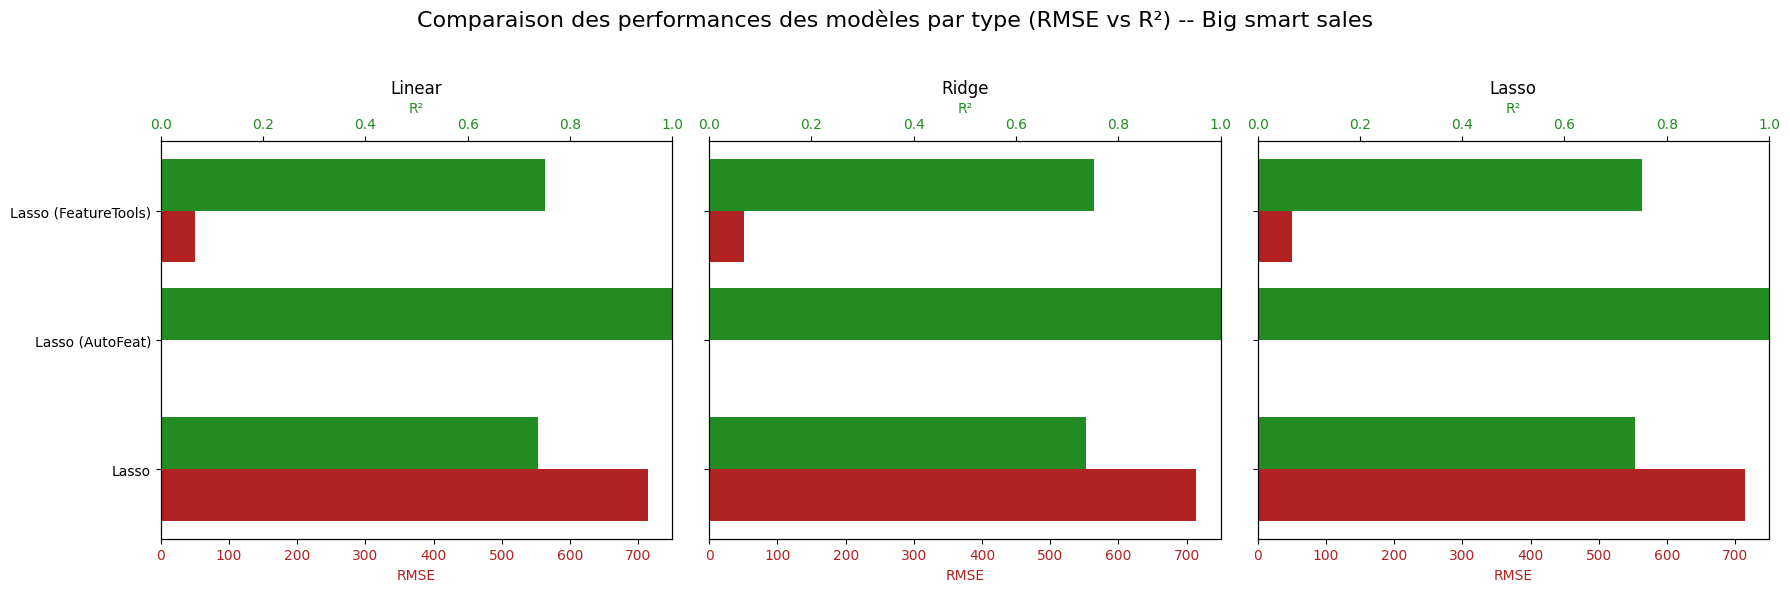

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Données organisées par type de modèle
model_groups = {
    "Linear": {
        "labels": ["Linear", "Linear (AutoFeat)", "Linear (FeatureTools)"],
        "rmse": [rmse, rmse_af, rmse_ft],
        "r2": [r2, r2_af, r2_ft]
    },
    "Ridge": {
        "labels": ["Ridge", "Ridge (AutoFeat)", "Ridge (FeatureTools)"],
        "rmse": [rmse_ridge, rmse_ridge_af, rmse_ridge_ft],
        "r2": [r2_ridge, r2_ridge_af, r2_ridge_ft]
    },
    "Lasso": {
        "labels": ["Lasso", "Lasso (AutoFeat)", "Lasso (FeatureTools)"],
        "rmse": [rmse_lasso, rmse_lasso_af, rmse_lasso_ft],
        "r2": [r2_lasso, r2_lasso_af, r2_lasso_ft]
    }
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (model_type, data) in enumerate(model_groups.items()):
    ax1 = axes[i]
    y = np.arange(len(data["labels"]))
    bar_height = 0.4

    # Axe principal : RMSE (rouge)
    ax1.barh(y - bar_height/2, data["rmse"], height=bar_height, color='firebrick', label='RMSE')
    ax1.set_xlabel('RMSE', color='firebrick')
    ax1.tick_params(axis='x', labelcolor='firebrick')
    ax1.set_yticks(y)
    ax1.set_yticklabels(data["labels"])
    ax1.set_title(model_type)

    # Axe secondaire : R² (vert)
    ax2 = ax1.twiny()
    ax2.barh(y + bar_height/2, data["r2"], height=bar_height, color='forestgreen', label='R²')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('R²', color='forestgreen')
    ax2.tick_params(axis='x', labelcolor='forestgreen')

fig.suptitle("Comparaison des performances des modèles par type (RMSE vs R²) -- Big smart sales", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
